In [1]:
import os

from dotenv import load_dotenv

load_dotenv(os.path.join("..", ".env"), override=True)

%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

# Deep Agent for Research

## Overview 

<img src="./assets/agent_header.png" width="800" style="display:block; margin-left:0;">

Now, we can put everything we have learned together:

* We will use **TODOs** to keep track of tasks. 
* We will use **files** to store raw tool call results. 
* We will **delegate research tasks to sub-agents** for context isolation. 

## Search Tool 

We'll build a search tool that offloads raw contents to files and returns only a summary to the agent. This is a common pattern for long-running agent trajectories, [as we've seen with Manus](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus)! 

### Core Components

1. **Search Execution (`run_tavily_search`)**: Performs the actual web search using Tavily API with configurable parameters for results count and topic filtering.

2. **Content Summarization (`summarize_webpage_content`)**: Uses a lightweight model (GPT-4o-mini) to generate structured summaries of webpage content, producing both a descriptive filename and key learnings summary.

3. **Result Processing (`process_search_results`)**: Fetches full webpage content via HTTP, converts HTML to markdown using `markdownify`, and generates summaries for each result.

4. **Context Offloading (`tavily_search` tool)**: The main tool that:
   - Executes search and processes results
   - Saves full content to files in agent state (context offloading)
   - Returns only minimal summaries to the agent (prevents context spam)
   - Uses LangGraph `Command` to update both files and messages

5. **Strategic Thinking (`think_tool`)**: Provides a structured reflection mechanism for agents to analyze findings, assess gaps, and plan next steps in their research workflow.

This architecture solves the token efficiency problem by storing detailed search results in files while keeping the agent's working context minimal and focused.

<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>Note:</b>  
The <code>create_react_agent</code> was moved from the LangGraph library to the LangChain library and renamed to <code>create_agent</code> in the 1.0 code release post-filming. There are slight changes to the imports and code to accommodate this. The video may display the previous configuration.
</div>

In [3]:
%%writefile ../src/deep_agents_from_scratch/research_tools.py
"""Research Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""
import os
from datetime import datetime
import uuid, base64

import httpx
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import InjectedToolArg, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from markdownify import markdownify
from pydantic import BaseModel, Field
from tavily import TavilyClient
from typing_extensions import Annotated, Literal

from deep_agents_from_scratch.prompts import SUMMARIZE_WEB_SEARCH
from deep_agents_from_scratch.state import DeepAgentState

# Summarization model 
BEDROCK_REGION = os.getenv("AWS_REGION") or os.getenv("AWS_DEFAULT_REGION") or "ap-southeast-1"
BEDROCK_MODEL_ID = os.getenv("BEDROCK_MODEL_ID", "anthropic.claude-3-5-sonnet-20241022-v2:0")
summarization_model = init_chat_model(model=f"bedrock_converse:{BEDROCK_MODEL_ID}", region_name=BEDROCK_REGION)
tavily_client = TavilyClient()

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    filename: str = Field(description="Name of the file to store.")
    summary: str = Field(description="Key learnings from the webpage.")

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def run_tavily_search(
    search_query: str, 
    max_results: int = 1, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> dict:
    """Perform search using Tavily API for a single query.

    Args:
        search_query: Search query to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        Search results dictionary
    """
    result = tavily_client.search(
        search_query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic
    )

    return result

def summarize_webpage_content(webpage_content: str) -> Summary:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Summary object with filename and summary
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary_and_filename = structured_model.invoke([
            HumanMessage(content=SUMMARIZE_WEB_SEARCH.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        return summary_and_filename
        
    except Exception:
        # Return a basic summary object on failure
        return Summary(
            filename="search_result.md",
            summary=webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content
        )


def process_search_results(results: dict) -> list[dict]:
    """Process search results by summarizing content where available.

    Args:
        results: Tavily search results dictionary

    Returns:
        List of processed results with summaries
    """
    processed_results = []

    # Create a client for HTTP requests with timeout
    HTTPX_CLIENT = httpx.Client(timeout=30.0)  # Add 30 second timeout

    for result in results.get('results', []):

        # Get url 
        url = result['url']

        # Read url with timeout and error handling
        try:
            response = HTTPX_CLIENT.get(url)
        
            if response.status_code == 200:
                # Convert HTML to markdown
                raw_content = markdownify(response.text)
                summary_obj = summarize_webpage_content(raw_content)
            else:
                # Use Tavily's generated summary
                raw_content = result.get('raw_content', '')
                summary_obj = Summary(
                    filename="URL_error.md",
                    summary=result.get('content', 'Error reading URL; try another search.')
                )
        except (httpx.TimeoutException, httpx.RequestError) as e:
            # Handle timeout or connection errors gracefully
            raw_content = result.get('raw_content', '')
            summary_obj = Summary(
                filename="connection_error.md",
                summary=result.get('content', f'Could not fetch URL (timeout/connection error). Try another search.')
            )

        # uniquify file names
        uid = base64.urlsafe_b64encode(uuid.uuid4().bytes).rstrip(b"=").decode("ascii")[:8]
        name, ext = os.path.splitext(summary_obj.filename)
        summary_obj.filename = f"{name}_{uid}{ext}"

        processed_results.append({
            'url': result['url'],
            'title': result['title'],
            'summary': summary_obj.summary,
            'filename': summary_obj.filename,
            'raw_content': raw_content,
        })

    return processed_results


@tool(parse_docstring=True)
def tavily_search(
    query: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> Command:
    """Search web and save detailed results to files while returning minimal context.

    Performs web search and saves full content to files for context offloading.
    Returns only essential information to help the agent decide on next steps.

    Args:
        query: Search query to execute
        state: Injected agent state for file storage
        tool_call_id: Injected tool call identifier
        max_results: Maximum number of results to return (default: 1)
        topic: Topic filter - 'general', 'news', or 'finance' (default: 'general')

    Returns:
        Command that saves full results to files and provides minimal summary
    """
    # Execute search
    search_results = run_tavily_search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    ) 

    # Process and summarize results
    processed_results = process_search_results(search_results)
    
    # Save each result to a file and prepare summary
    files = state.get("files", {})
    saved_files = []
    summaries = []
    
    for i, result in enumerate(processed_results):
        # Use the AI-generated filename from summarization
        filename = result['filename']
        
        # Create file content with full details
        file_content = f"""# Search Result: {result['title']}

**URL:** {result['url']}
**Query:** {query}
**Date:** {get_today_str()}

## Summary
{result['summary']}

## Raw Content
{result['raw_content'] if result['raw_content'] else 'No raw content available'}
"""
        
        files[filename] = file_content
        saved_files.append(filename)
        summaries.append(f"- {filename}: {result['summary']}...")
    
    # Create minimal summary for tool message - focus on what was collected
    summary_text = f"""🔍 Found {len(processed_results)} result(s) for '{query}':

{chr(10).join(summaries)}

Files: {', '.join(saved_files)}
💡 Use read_file() to access full details when needed."""

    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(summary_text, tool_call_id=tool_call_id)
            ],
        }
    )

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    - How complex is the question: Have I reached the number of search limits?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

Overwriting ../src/deep_agents_from_scratch/research_tools.py


## Deep Agent

Now, we can just apply all of our prior learnings: 

* We'll give the researcher a `think_tool` and our `search_tool` above.
* We'll give our parent agent file tools, a `think_tool`, and a `task` tool. 

In [4]:
from datetime import datetime

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from utils import show_prompt, stream_agent

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.prompts import (
    FILE_USAGE_INSTRUCTIONS,
    RESEARCHER_INSTRUCTIONS,
    SUBAGENT_USAGE_INSTRUCTIONS,
    TODO_USAGE_INSTRUCTIONS,
)
from deep_agents_from_scratch.research_tools import tavily_search, think_tool, get_today_str
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool
from deep_agents_from_scratch.todo_tools import write_todos, read_todos

# Create agent using create_react_agent directly
BEDROCK_REGION = os.getenv("AWS_REGION", "ap-southeast-1")
BEDROCK_MODEL_ID = os.getenv("BEDROCK_MODEL_ID")
model = init_chat_model(model=f"bedrock_converse:{BEDROCK_MODEL_ID}", region_name=BEDROCK_REGION, temperature=0.0)

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Tools
sub_agent_tools = [tavily_search, think_tool]
built_in_tools = [ls, read_file, write_file, write_todos, read_todos, think_tool]

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": ["tavily_search", "think_tool"],
}

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

delegation_tools = [task_tool]
all_tools = sub_agent_tools + built_in_tools + delegation_tools  # search available to main agent for trivial cases

# Build prompt
SUBAGENT_INSTRUCTIONS = SUBAGENT_USAGE_INSTRUCTIONS.format(
    max_concurrent_research_units=max_concurrent_research_units,
    max_researcher_iterations=max_researcher_iterations,
    date=datetime.now().strftime("%a %b %-d, %Y"),
)

In [5]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 1-2 search tool calls maximum                                                        │
│  - **Normal queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Very Complex queries**: Use up to 5 search tool calls maximum                                              │
│  - **Always stop**: After 5 search tool calls if you c

In [6]:
INSTRUCTIONS = (
    "# TODO MANAGEMENT\n"
    + TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# FILE SYSTEM USAGE\n"
    + FILE_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# SUB-AGENT DELEGATION\n"
    + SUBAGENT_INSTRUCTIONS
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # TODO MANAGEMENT                                                                                              │
│  Based upon the user's request:                                                                                 │
│  1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.           │
│  2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan.  │
│  3. Reflect on what you've done and the TODO.                                                                   │
│  4. Mark you task as completed, and proceed to the next TODO.                                                   │
│  5. Continue this process until you have completed all TODOs.                                                   │
│                                                                                                                 │
│  IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY  │
│  user request.                                                                                                  │
│  IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have  │
│  to keep track of.                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # FILE SYSTEM USAGE                                                                                            │
│  You have access to a virtual file system to help you retain and save context.                                  │
│                                                                                                                 │
│  ## Workflow Process                                                                                            │
│  1. **Orient**: Use ls() to see existing files before starting work                                             │
│  2. **Save**: Use write_file() to store the user's request so that we can keep it for later                     │
│  3. **Research**: Proceed with research. The search tool will write files.                                      │
│  4. **Read**: Once you are satisfied with the collected sources, read the files and use them to answer the      │
│  user's question directly.                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # SUB-AGENT DELEGATION                                                                                         │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                               

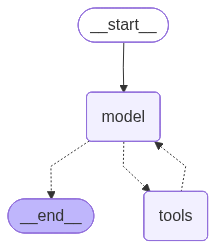

In [7]:
# Create agent
agent = create_agent(  #updated 1.0
    model, all_tools, system_prompt=INSTRUCTIONS, state_schema=DeepAgentState
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [8]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Okay, let's research the Model Context Protocol (MCP) using a structured research plan.                         │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research what the Model Context Protocol (MCP) is",                                           │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Summarize the key features and purpose of MCP",                                               │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Provide an overview of MCP that answers the user's request",                                  │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: tooluse_QGgIgegOuUfPIybnw6GgFT                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Research what the Model Context Protocol (MCP) is', 'status': 'pending'},    │
│ {'content': 'Summarize the key features and purpose of MCP', 'status': 'pending'}, {'content': "Provide an      │
│ overview of MCP that answers the user's request", 'status': 'pending'}]                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Okay, let's start by researching what the Model Context Protocol (MCP) is.                                      │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol (MCP)"                                                                       │
│ }                                                                                                               │
│    ID: tooluse_MJInUUic04p6HPF86WFfrh                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 🔍 Found 1 result(s) for 'Model Context Protocol (MCP)':                                                        │
│                                                                                                                 │
│ - mcp_protocol_overview_5fCgrKQc.md: This course provides an introduction to the Model Context Protocol (MCP),  │
│ a framework for connecting AI models like Claude to external services. Key topics covered include MCP's         │
│ architecture, primitives (tools, resources, prompts), and implementation in Python. The focus is on building    │
│ both MCP servers and clients to integrate AI models into applications....                                       │
│                                                                                                                 │
│ Files: mcp_protocol_overview_5fCgrKQc.md                                                                        │
│ 💡 Use read_file() to access full details when needed.                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "mcp_protocol_overview_5fCgrKQc.md"                                                              │
│ }                                                                                                               │
│    ID: tooluse_gSVnA4UVp5ULCtnZd2VuPq                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│      1  # Search Result: Introduction to Model Context Protocol - Anthropic Skilljar                            │
│      2                                                                                                          │
│      3  **URL:** https://anthropic.skilljar.com/introduction-to-model-context-protocol                          │
│      4  **Query:** Model Context Protocol (MCP)                                                                 │
│      5  **Date:** Fri Apr 17, 2026                                                                              │
│      6                                                                                                          │
│      7  ## Summary                                                                                              │
│      8  This course provides an introduction to the Model Context Protocol (MCP), a framework for connecting AI │
│ models like Claude to external services. Key topics covered include MCP's architecture, primitives (tools,      │
│ resources, prompts), and implementation in Python. The focus is on building both MCP servers and clients to     │
│ integrate AI models into applications.                                                                          │
│      9                                                                                                          │
│     10  ## Raw Content                                                                                          │
│     11  Introduction to Model Context Protocol                                                                  │
│     12                                                                                                          │
│     13                                                                                                          │
│     14                                                                                                          │
│     15  [![Go                                                                                                   │
│ home](https://cc.sj-cdn.net/instructor/4hdejjwplbrm-anthropic/themes/3gufixqhei80k/header-logo.1749494808.png)] │
│ (https://anthropic.com)                                                                                         │
│     16                                                                                                          │
│     17  Header Navigation                                                                                       │
│     18  -----------------                                                                                       │
│     19                                                                                                          │
│     20  [Anthropic Academy](https://www.anthropic.com/learn)                                                    │
│     21  [Courses](/)                                                                                            │
│     22                                                                                                          │
│     23  [Sign In](/auth/login?next=%2Fintroduction-to-model-context-protocol)                                   │
│     24                                                                                                          │
│     25  [Anthropic Academy](https://www.anthropic.com/learn)                                                    │
│     26  [Courses](/)                                                                                            │
│     27                                                                                                          │
│     28  [Sign In](/auth/login?next=%2Fintroduction-to-model-context-protocol)                                   │
│     29                                                 

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The detailed course overview provides a comprehensive understanding of the Model Context       │
│ Protocol (MCP):\n\nKey Features and Purpose:\n- MCP is a framework for connecting AI models like Claude to      │
│ external services and applications\n- It has 3 core primitives: tools, resources, and prompts\n- Tools are      │
│ model-controlled, resources are app-controlled, and prompts are user-controlled\n- MCP shifts the burden of     │
│ tool definition and execution from the client app to specialized MCP servers\n- It has a transport-agnostic     │
│ communication system with defined message types between clients and servers\n- MCP enables building powerful    │
│ applications that integrate with AI models without extensive custom integration code\n\nThe course covers how   │
│ to build both MCP servers and clients using the Python SDK, including defining tools, resources, and prompts.   │
│ It also discusses practical integration patterns like autocomplete and context injection.\n\nI now have a good  │
│ understanding of what MCP is and its key features/purpose to provide a comprehensive overview to the user. I    │
│ believe I have enough information to answer their original request."                                            │
│ }                                                                                                               │
│    ID: tooluse_CqWIPTCNe1csKYOkMKebfF                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The detailed course overview provides a comprehensive understanding of the Model Context   │
│ Protocol (MCP):                                                                                                 │
│                                                                                                                 │
│ Key Features and Purpose:                                                                                       │
│ - MCP is a framework for connecting AI models like Claude to external services and applications                 │
│ - It has 3 core primitives: tools, resources, and prompts                                                       │
│ - Tools are model-controlled, resources are app-controlled, and prompts are user-controlled                     │
│ - MCP shifts the burden of tool definition and execution from the client app to specialized MCP servers         │
│ - It has a transport-agnostic communication system with defined message types between clients and servers       │
│ - MCP enables building powerful applications that integrate with AI models without extensive custom integration │
│ code                                                                                                            │
│                                                                                                                 │
│ The course covers how to build both MCP servers and clients using the Python SDK, including defining tools,     │
│ resources, and prompts. It also discusses practical integration patterns like autocomplete and context          │
│ injection.                                                                                                      │
│                                                                                                                 │
│ I now have a good understanding of what MCP is and its key features/purpose to provide a comprehensive overview │
│ to the user. I believe I have enough information to answer their original request.                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ <result>                                                                                                        │
│ Here is an overview of the Model Context Protocol (MCP):                                                        │
│                                                                                                                 │
│ MCP is a framework developed by Anthropic for connecting AI models like Claude to external services and         │
│ applications. It has three core primitives:                                                                     │
│                                                                                                                 │
│ 1. **Tools**: Model-controlled functionality that can be invoked by the AI model. Tools shift the burden of     │
│ definition and execution from the client app to specialized MCP servers.                                        │
│                                                                                                                 │
│ 2. **Resources**: App-controlled data sources that the AI model can access, such as documents or databases.     │
│ Resources allow the app to expose read-only data to the model.                                                  │
│                                                                                                                 │
│ 3. **Prompts**: User-controlled instructions that provide pre-crafted, high-quality guidance for common         │
│ workflows like document formatting.                                                                             │
│                                                                                                                 │
│ The key purpose of MCP is to enable building powerful applications that integrate with AI models without        │
│ requiring extensive custom integration code. It has a transport-agnostic communication system with defined      │
│ message types between MCP clients and servers.                                                                  │
│                                                                                                                 │
│ Some of the key features of MCP include:                                                                        │
│                                                                                                                 │
│ - Shifting tool definition and execution burden to specialized MCP servers                                      │
│ - Providing a consistent, standardized way to connect AI models to external services                            │
│ - Enabling practical integration patterns like autocomplete and context injection                               │
│ - Allowing apps to expose read-only data sources (resources) to the AI model                                    │
│ - Providing pre-crafted prompts for common user workflows                                                       │
│                                                                                                                 │
│ Overall, MCP is a framework that simplifies the integration of AI models like Claude into applications by       │
│ providing a set of standardized primitives and communication protocols. It aims to make it easier for           │
│ developers to build applications that leverage the capabilities of advanced language models.                    │
│ </result>                                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Trace: 
https://smith.langchain.com/public/3a389ec6-8e6e-4f9e-9a82-0d0a9569e6f8/r
<!-- https://smith.langchain.com/public/1df7a10e-1465-499c-a3e0-86c1d5429324/r -->

## Using the Deep Agent Package

Now you understand the underlying patterns! 

You can [use the `deepagents` package](
https://github.com/hwchase17/deepagents) as a simple abstraction:

* It include the file system tools
* It includes the todo tool
* It includes the task tool

You only need to supply the sub-agent and any tools you want the sub-agent to use.

In [9]:
from deepagents import create_deep_agent
# updated since filming

# Create research sub-agent
research_sub_agent_2 = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": [tavily_search, think_tool],
}


agent = create_deep_agent(  # updated 
    tools=sub_agent_tools,
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent_2],
    model=model,
)

# Show the agent
#display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [10]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an very brief overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

format_messages(result["messages"])

/Users/sujanp/Desktop/LangChain/Deepagents/deep-agents-from-scratch/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `general-fields` - serialized value may not be as expected [field_name='files', input_value='# Search Result: Introdu...://www.skilljar.com/)\n', input_type=str])
  return self.__pydantic_serializer__.to_python(


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an very brief overview of Model Context Protocol (MCP).                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research Model Context Protocol (MCP)",                                                       │
│       "status": "in_progress"                                                                                   │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: tooluse_Xjj7Li6aXQM3YXuYhu50sp                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Research Model Context Protocol (MCP)', 'status': 'in_progress'}]            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol (MCP)"                                                                       │
│ }                                                                                                               │
│    ID: tooluse_IAthyE99tc472agelgGPjs                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "/mcp_protocol_overview_vc-SOzl4.md"                                                             │
│ }                                                                                                               │
│    ID: tooluse_Tlh55NTaYl3iZNHs4XBMuG                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Error: File '/mcp_protocol_overview_vc-SOzl4.md' not found                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The search results indicate that there is a file with more detailed information about MCP, but │
│ it seems that file is not currently available in the file system. I will try to summarize the key points from   │
│ the high-level overview I was able to find."                                                                    │
│ }                                                                                                               │
│    ID: tooluse_krLQDrkUrK5hO7sP81qvQx                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The search results indicate that there is a file with more detailed information about MCP, │
│ but it seems that file is not currently available in the file system. I will try to summarize the key points    │
│ from the high-level overview I was able to find.                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ <result>                                                                                                        │
│ In summary, the Model Context Protocol (MCP) is a framework for integrating AI models like Claude with external │
│ services and capabilities. Key points about MCP:                                                                │
│                                                                                                                 │
│ - It provides a way to define tools, resources, and prompts that can enhance an AI model's capabilities without │
│ extensive integration code.                                                                                     │
│ - The goal is to allow AI models to seamlessly access and utilize external services and data sources to improve │
│ their performance and functionality.                                                                            │
│ - MCP enables AI models to be extended and customized for specific use cases or applications by defining the    │
│ appropriate tools, resources, and prompts.                                                                      │
│                                                                                                                 │
│ While I was not able to access the full details on MCP, this high-level overview suggests it is a protocol or   │
│ framework that aims to make it easier to integrate AI models with other systems and services. The key benefit   │
│ seems to be the ability to enhance an AI model's capabilities without complex integration work.                 │
│ </result>                                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Trace: 
https://smith.langchain.com/public/1d626d81-a102-4588-a2fb-cab40a7271f1/r
<!-- https://smith.langchain.com/public/1ae2d7f6-f901-4ebd-b6c3-6657a55f88ae/r -->